In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

In [7]:
data = pd.DataFrame(columns = ['sched', 'hyper', 'n_load', 'sim_time'])
data.loc[len(data)] = ['graph_test', 0, 23090, 48.299]
data.loc[len(data)] = ['graph_test', 1, 23123, 53.280]
data.loc[len(data)] = ['graph_test', 2, 17337, 9.942]
data.loc[len(data)] = ['graph_test', 3, 16459, 11.030]
data.loc[len(data)] = ['new_v2', 1, 17366, 10.526]
data.loc[len(data)] = ['new_v2', 2, 18079, 12.269]
data.loc[len(data)] = ['new_v2', 3, 18323, 12.782]
data.loc[len(data)] = ['new_v2', 4, 18583, 13.323]
data.loc[len(data)] = ['new_v2', 5, 18585, 13.294]
data.loc[len(data)] = ['new_v2', 6, 18560, 13.221]
data.loc[len(data)] = ['new_v2', 7, 18788, 13.754]

In [8]:
def addlabels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                '%d' % int(height),
                ha='center', va='bottom')

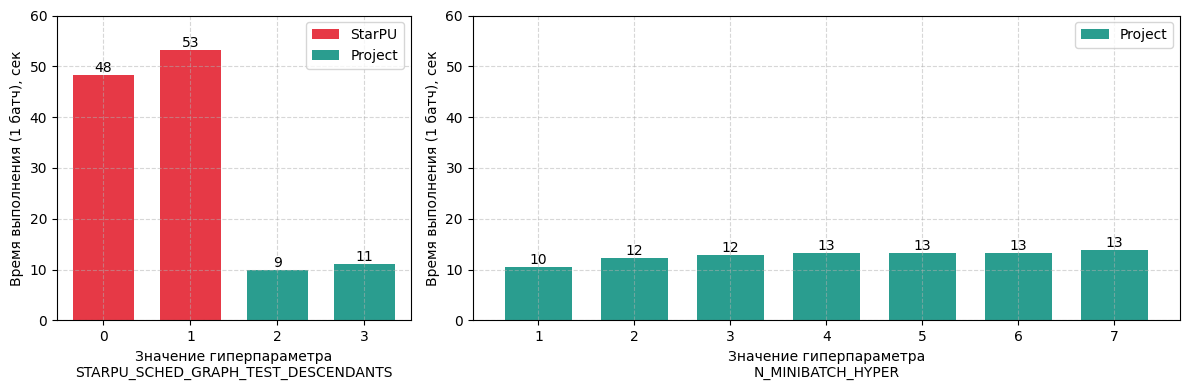

In [9]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])

df = data.query('sched=="graph_test"')
df_starpu = df[df['hyper'] < 2]
df_project = df[df['hyper'] >= 2]

bar_width = 0.7 #  Фиксированная ширина столбцов

bars1 = ax1.bar(df_starpu['hyper'], df_starpu['sim_time'], width=bar_width, color='#E63946', label='StarPU')
bars2 = ax1.bar(df_project['hyper'], df_project['sim_time'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars1) #  Функция addlabels() должна быть определена где-то выше
addlabels(bars2)

ax1.set_xlabel('Значение гиперпараметра\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS')
ax1.set_ylabel('Время выполнения (1 батч), сек')
ax1.grid(linestyle='--', alpha=0.5)
ax1.set_xticks(np.arange(4))
ax1.set_ylim(0, 60)
ax1.legend()


# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])

df = data.query('sched=="new_v2"')
bars = ax2.bar(df['hyper'], df['sim_time'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars)

ax2.set_xlabel('Значение гиперпараметра\nN_MINIBATCH_HYPER')
ax2.set_ylabel('Время выполнения (1 батч), сек')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xticks(np.arange(1, 8))
ax2.set_ylim(0, 60)
ax2.legend()


plt.tight_layout() #  Для лучшего расположения элементов
plt.show()

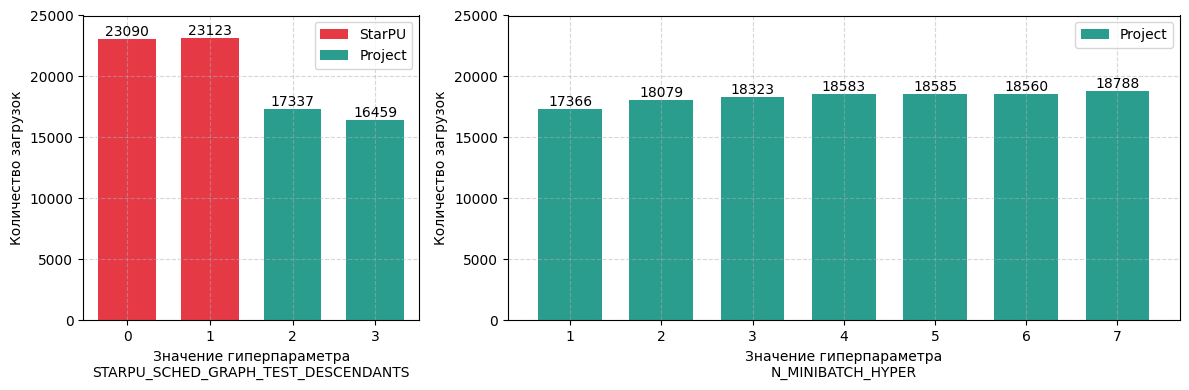

In [10]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])

df = data.query('sched=="graph_test"')
df_starpu = df[df['hyper'] < 2]
df_project = df[df['hyper'] >= 2]

bar_width = 0.7 #  Фиксированная ширина столбцов

bars1 = ax1.bar(df_starpu['hyper'], df_starpu['n_load'], width=bar_width, color='#E63946', label='StarPU')
bars2 = ax1.bar(df_project['hyper'], df_project['n_load'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars1) #  Функция addlabels() должна быть определена где-то выше
addlabels(bars2)

ax1.set_xlabel('Значение гиперпараметра\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS')
ax1.set_ylabel('Количество загрузок')
ax1.grid(linestyle='--', alpha=0.5)
ax1.set_xticks(np.arange(4))
ax1.set_ylim(0, 25000)
ax1.legend()


# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])

df = data.query('sched=="new_v2"')
bars = ax2.bar(df['hyper'], df['n_load'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars)

ax2.set_xlabel('Значение гиперпараметра\nN_MINIBATCH_HYPER')
ax2.set_ylabel('Количество загрузок')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xticks(np.arange(1, 8))
ax2.set_ylim(0, 25000)
ax2.legend()


plt.tight_layout() #  Для лучшего расположения элементов
plt.show()